# HCE + Cell2Sentence — End-to-End Pipeline (Option A)

**Hierarchical Cross-Entropy (HCE) loss** applied to a C2S encoder + classification head
for lung cell type classification.

### Option A: mixed-granularity labels
Each cell carries labels at *every* valid annotation level (`ann_level_1` → `ann_finest_level`).
During training one level is randomly sampled per step, so **coarser classes become real
training targets** — the reachability matrix then actively propagates gradient from
fine-grained predictions up to parent nodes.  This is what makes HCE strictly better than CE.

### Key implementation points
| Component | Choice | Reason |
|-----------|--------|--------|
| Training labels | random level per step | activates HCE hierarchy |
| Class space | all observed labels (all levels) | coarser nodes are real targets |
| HCE loss | `-w_t log(s_t + ε)`, Eq. 7 | weighted, per paper |
| Pooling | last non-padding token | correct for decoder-only (Pythia) LM |
| Eval labels | always finest level | standard leaf-level metric |


## 1. Imports

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter

import scanpy as sc
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

sys.path.insert(0, '/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/src')
from cell2sentence.hce_trainer import build_reachability_matrix_from_ontology

print("Libraries imported successfully.")



/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/c2s-justin/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.


## 2. Configuration

In [2]:
LUNG_H5AD_PATH  = '/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung.h5ad'
OUT_DIR         = '/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung_hce_option_a_results'
BEST_MODEL_PATH = os.path.join(OUT_DIR, 'best_model.pt')
os.makedirs(OUT_DIR, exist_ok=True)

C2S_MODEL_NAME    = 'vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation'
TOP_K_GENES       = 100
ANN_COL           = 'ann_finest_level'   # finest-level annotation column
MAX_CELLS_PER_TYPE = 1000
MIN_CELLS_PER_TYPE = 20

BATCH_SIZE    = 8
LEARNING_RATE = 1e-4
N_EPOCHS      = 10
WARMUP_STEPS  = 500
WEIGHT_DECAY  = 0.01
TRAIN_FRAC    = 0.70
VAL_FRAC      = 0.15
TEST_FRAC     = 0.15
RANDOM_SEED   = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

def get_device():
    if torch.cuda.is_available():
        d = torch.device("cuda"); print(f"GPU: {torch.cuda.get_device_name(0)}")
    elif torch.backends.mps.is_available():
        d = torch.device("mps");  print("MPS")
    else:
        d = torch.device("cpu");  print("CPU")
    return d

device = get_device()
print(f"Output dir: {OUT_DIR}")


GPU: NVIDIA GeForce RTX 5060 Ti
Output dir: /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung_hce_option_a_results


## 3. Load and Balance Dataset

In [3]:
print("Loading dataset...")
adata = sc.read_h5ad(LUNG_H5AD_PATH, backed='r')
print(f"  Raw shape: {adata.shape}")

labels_raw = adata.obs[ANN_COL].astype(str)
counts_raw = labels_raw.value_counts()

keep_labels = counts_raw[counts_raw >= MIN_CELLS_PER_TYPE].index.tolist()
print(f"  Keeping {len(keep_labels)} classes with >= {MIN_CELLS_PER_TYPE} cells")

sampled_idx = []
for lbl in keep_labels:
    idxs   = np.where(labels_raw.values == lbl)[0]
    n_keep = min(len(idxs), MAX_CELLS_PER_TYPE)
    sampled_idx.extend(np.random.choice(idxs, n_keep, replace=False).tolist())

sampled_idx = np.sort(sampled_idx)
adata_b     = adata[sampled_idx].to_memory()

invalid = ['unknown','Unknown','UNKNOWN','nan','NA','N/A','none','None']
valid_mask = ~adata_b.obs[ANN_COL].isin(invalid)
adata_b    = adata_b[valid_mask].copy()

print(f"  Balanced: {adata_b.n_obs} cells, {adata_b.obs[ANN_COL].nunique()} types")


Loading dataset...
  Raw shape: (2282447, 55329)
  Keeping 62 classes with >= 20 cells
  Balanced: 57611 cells, 61 types


## 4. Build Cell Type Hierarchy

In [4]:
def is_valid_annotation(value):
    if pd.isna(value): return False
    s = str(value).strip().lower()
    return s not in ('unknown','none','na','n/a','nan','')

# Discover hierarchical annotation level columns
level_columns = sorted([c for c in adata_b.obs.columns
                        if c.startswith('ann_level_') and c[-1].isdigit()])
print(f"Annotation levels found: {level_columns}")

# Build parent-child ontology dict
ontology_dict  = {}
all_hier_nodes = set()

for idx in range(len(adata_b.obs)):
    valid_path = []
    for col in level_columns:
        val = adata_b.obs.iloc[idx][col]
        if is_valid_annotation(val):
            valid_path.append(str(val))
        else:
            break
    leaf_val = adata_b.obs.iloc[idx][ANN_COL]
    if is_valid_annotation(leaf_val):
        valid_path.append(str(leaf_val))

    for node in valid_path:
        all_hier_nodes.add(node)
    for i in range(len(valid_path) - 1):
        child, parent = valid_path[i+1], valid_path[i]
        if child not in ontology_dict:
            ontology_dict[child] = parent

# Root nodes have no parent
for idx in range(len(adata_b.obs)):
    val = adata_b.obs.iloc[idx]['ann_level_1']
    if is_valid_annotation(val) and str(val) not in ontology_dict:
        ontology_dict[str(val)] = None

n_edges = sum(1 for v in ontology_dict.values() if v is not None)
print(f"Ontology: {len(all_hier_nodes)} nodes, {n_edges} parent-child edges")

pd.DataFrame(list(ontology_dict.items()), columns=['child','parent']).to_csv(
    os.path.join(OUT_DIR, 'ontology.csv'), index=False)


Annotation levels found: ['ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5']
Ontology: 93 nodes, 89 parent-child edges


## 5. Prepare Cell Text Data (Option A labels)

In [5]:
def cell_to_text(cell_vector, gene_names, top_k=100):
    vec = cell_vector.toarray().flatten() if hasattr(cell_vector,'toarray') else np.asarray(cell_vector).flatten()
    if vec.size == 0: return ""
    top_idx  = np.argsort(vec)[-top_k:][::-1]
    return " ".join(str(gene_names[i]) for i in top_idx if gene_names[i])

print(f"Converting {adata_b.n_obs} cells to text (top-{TOP_K_GENES} genes)...")
all_texts = [cell_to_text(adata_b.X[i], adata_b.var_names, TOP_K_GENES)
             for i in range(adata_b.n_obs)]

keep_idx    = [i for i, t in enumerate(all_texts) if t.strip()]
cell_texts  = [all_texts[i] for i in keep_idx]
cell_labels = adata_b.obs[ANN_COL].iloc[keep_idx].astype(str).values
print(f"  Kept {len(cell_texts)} non-empty cells")

# ── Option A: multi-granularity labels ──────────────────────────────────────
# For each cell collect every valid annotation level (coarsest → finest).
# During training one is sampled randomly each step → coarser nodes become
# real targets → the reachability matrix actively shapes gradients.
level_columns_all = level_columns + [ANN_COL]   # coarser → finest
cell_all_labels   = []   # list[list[str]]

for orig_i in keep_idx:
    path = []
    for col in level_columns_all:
        val = adata_b.obs.iloc[orig_i][col]
        if is_valid_annotation(val):
            path.append(str(val))
        else:
            break
    cell_all_labels.append(path if path else [cell_labels[len(cell_all_labels)]])

n_levels_avg         = np.mean([len(p) for p in cell_all_labels])
unique_across_levels = set(l for p in cell_all_labels for l in p)
print(f"  Average annotation levels per cell : {n_levels_avg:.2f}")
print(f"  Unique labels across all levels    : {len(unique_across_levels)}")


Converting 57611 cells to text (top-100 genes)...
  Kept 57611 non-empty cells
  Average annotation levels per cell : 4.33
  Unique labels across all levels    : 93


## 6. Class Vocabulary and Dataset

In [6]:
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(C2S_MODEL_NAME)

# Class space = union of all labels at all annotation levels
all_observed_labels = set(l for p in cell_all_labels for l in p)
class_names  = sorted(all_observed_labels)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

# Leaf classes = finest-level only (evaluation target)
leaf_classes = sorted({l for l in adata_b.obs[ANN_COL].unique() if l in class_to_idx})
leaf_to_idx  = {l: class_to_idx[l] for l in leaf_classes}
leaf_indices = [class_to_idx[l] for l in leaf_classes]
leaf_index_set = set(leaf_indices)

print(f"Class vocab  : {len(class_names)} total ({len(leaf_classes)} leaf, {len(class_names)-len(leaf_classes)} coarser)")

# Encode multi-level labels per cell as index lists
cell_all_labels_encoded = [
    [class_to_idx[l] for l in path if l in class_to_idx]
    for path in cell_all_labels
]
# Finest-level index for stratified splitting / evaluation
labels_encoded = np.array([class_to_idx[cell_labels[i]] for i in range(len(cell_labels))], dtype=int)

class CellTextDataset(Dataset):
    """
    Option A Dataset.
    Training  : randomly samples one annotation level per cell per step.
    Evaluation: always uses the finest-level label (last entry in path).
    """
    def __init__(self, texts, all_labels_encoded, tokenizer, max_length=512, is_train=True):
        self.texts              = texts
        self.all_labels_encoded = all_labels_encoded
        self.tokenizer          = tokenizer
        self.max_length         = max_length
        self.is_train           = is_train

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        labels = self.all_labels_encoded[idx]
        label  = labels[np.random.randint(len(labels))] if self.is_train else labels[-1]
        enc    = self.tokenizer(self.texts[idx], padding="max_length",
                                truncation=True, max_length=self.max_length,
                                return_tensors="pt")
        return {"input_ids":      enc["input_ids"].squeeze(),
                "attention_mask": enc["attention_mask"].squeeze(),
                "labels":         torch.tensor(label, dtype=torch.long)}

# Stratified split by finest-level label
idx_all = np.arange(len(labels_encoded))
idx_tv, idx_test, y_tv, y_test = train_test_split(
    idx_all, labels_encoded, test_size=TEST_FRAC, stratify=labels_encoded, random_state=RANDOM_SEED)
idx_train, idx_val, y_train, y_val = train_test_split(
    idx_tv, y_tv, test_size=VAL_FRAC/(TRAIN_FRAC+VAL_FRAC), stratify=y_tv, random_state=RANDOM_SEED)

print(f"Split: train={len(idx_train)}, val={len(idx_val)}, test={len(idx_test)}")

def make_loader(idxs, is_train):
    texts  = [cell_texts[i] for i in idxs]
    labels = [cell_all_labels_encoded[i] for i in idxs]
    return DataLoader(CellTextDataset(texts, labels, tokenizer, is_train=is_train),
                      batch_size=BATCH_SIZE, shuffle=is_train)

train_loader = make_loader(idx_train, True)
val_loader   = make_loader(idx_val,   False)
test_loader  = make_loader(idx_test,  False)
print("DataLoaders ready.")


Loading tokenizer...
Class vocab  : 93 total (61 leaf, 32 coarser)
Split: train=40327, val=8642, test=8642
DataLoaders ready.


## 7. Model Architecture

In [7]:
print("Loading C2S encoder...")
c2s_model   = AutoModel.from_pretrained(C2S_MODEL_NAME)
hidden_size = c2s_model.config.hidden_size
print(f"  Hidden size: {hidden_size}")

class ClassificationHead(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.net(x)

class C2SClassifier(nn.Module):
    def __init__(self, encoder, num_classes, hidden_size):
        super().__init__()
        self.encoder    = encoder
        self.classifier = ClassificationHead(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out         = self.encoder(input_ids, attention_mask=attention_mask)
        last_hidden = out.last_hidden_state                # (B, T, H)

        # Last non-padding token pooling.
        # C2S is Pythia (decoder-only causal LM): the last real token attends
        # to the full sequence — it is the correct sequence representation.
        # Mean pooling (used in encoder-only models) is wrong here because
        # early positions have only seen partial context.
        seq_len    = attention_mask.sum(dim=1) - 1         # (B,)
        last_token = last_hidden[torch.arange(last_hidden.size(0), device=last_hidden.device), seq_len]
        return self.classifier(last_token)

model = C2SClassifier(c2s_model, len(class_names), hidden_size)
model.to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model on {device}  |  {n_params/1e6:.1f}M trainable params  |  {len(class_names)} output classes")


Loading C2S encoder...


Loading weights: 100%|██████████| 291/291 [00:00<00:00, 340.46it/s, Materializing param=layers.23.post_attention_layernorm.weight] 
GPTNeoXModel LOAD REPORT from: vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation
Key              | Status     |  | 
-----------------+------------+--+-
embed_out.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Hidden size: 1024
Model on cuda  |  354.1M trainable params  |  93 output classes


## 8. Reachability Matrix and Weighted HCE Loss

In [8]:
print("Building reachability matrix...")

# Use the utility from hce_trainer.py
R_np = build_reachability_matrix_from_ontology(ontology_dict, class_names)
reachability_matrix = torch.tensor(R_np, dtype=torch.float32, device=device)

nz = int((reachability_matrix > 0).sum().item())
print(f"  Shape: {tuple(reachability_matrix.shape)}")
print(f"  Non-zero entries (incl. diagonal): {nz}")
print(f"  Off-diagonal (hierarchy) entries : {nz - len(class_names)}")

# Coarser-level class indices (appear as targets during training)
ancestor_indices = [i for i in range(len(class_names)) if i not in leaf_index_set]
print(f"  Coarser classes that become training targets: {len(ancestor_indices)}")

# ── Class weights  w_i = N / (C * n_i)  (paper Eq. 7) ──────────────────────
# Leaf weights: from direct finest-level training counts.
# Coarser weights: effective count = sum of descendant leaf counts.
train_counts = Counter(y_train.tolist())
N_train      = len(y_train)
C_obs        = len(train_counts)

class_weights = torch.zeros(len(class_names), dtype=torch.float32, device=device)

for label_idx, cnt in train_counts.items():          # leaf weights
    class_weights[label_idx] = N_train / (C_obs * cnt)

for anc_idx in ancestor_indices:                     # coarser weights
    eff = sum(train_counts.get(j, 0)
              for j in leaf_indices
              if reachability_matrix[anc_idx, j] > 0)
    if eff > 0:
        class_weights[anc_idx] = N_train / (C_obs * eff)

nzw = (class_weights > 0).sum().item()
print(f"  Class weights: {nzw}/{len(class_names)} non-zero, "
      f"range [{class_weights[class_weights>0].min():.4f}, {class_weights.max():.4f}]")

# ── Weighted HCE Loss (paper Eqs. 4 & 7) ─────────────────────────────────────
class HCELoss(nn.Module):
    """
    Hierarchical Cross-Entropy Loss.

    s_i  = sum_j R[i,j] * p_j   (paper Eq. 4)  via  s = probs @ R.T
    L    = -w_t * log(s_t + eps) (paper Eq. 7)

    R[parent, child] = 1  (parent→child semantics, with transitive closure).
    """
    def __init__(self, R, class_weights=None, eps=1e-8):
        super().__init__()
        self.register_buffer("R", R)
        self.eps = eps
        if class_weights is not None:
            self.register_buffer("class_weights", class_weights)
        else:
            self.class_weights = None

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)                 # [B, C]
        s     = probs @ self.R.T                             # [B, C]  Eq. 4
        s     = torch.clamp(s, min=self.eps)
        log_s = torch.log(s)                                 # [B, C]
        bidx  = torch.arange(len(targets), device=targets.device)
        log_st = log_s[bidx, targets]                        # [B]     Eq. 5

        if self.class_weights is not None:
            loss = -(self.class_weights[targets] * log_st).mean()   # Eq. 7
        else:
            loss = -log_st.mean()
        return loss

hce_criterion = HCELoss(reachability_matrix, class_weights=class_weights)
print("HCE loss initialized  (weighted, paper Eq. 7)")
print("  s = softmax(logits) @ R.T")
print("  L = -w_t * log(s_t + eps)")


Building reachability matrix...
  Shape: (93, 93)
  Non-zero entries (incl. diagonal): 330
  Off-diagonal (hierarchy) entries : 237
  Coarser classes that become training targets: 32
  Class weights: 93/93 non-zero, range [0.0430, 34.7947]
HCE loss initialized  (weighted, paper Eq. 7)
  s = softmax(logits) @ R.T
  L = -w_t * log(s_t + eps)


## 9. Verification

In [9]:
n = reachability_matrix.shape[0]
diag_ok = torch.allclose(torch.diag(reachability_matrix),
                         torch.ones(n, device=reachability_matrix.device))
print(f"Diagonal = identity : {diag_ok}")
print(f"Matrix shape        : {tuple(reachability_matrix.shape)}")

# Edge direction check
valid, checked = 0, 0
for child, parent in ontology_dict.items():
    if parent is None or child not in class_to_idx or parent not in class_to_idx:
        continue
    checked += 1
    p, c = class_to_idx[parent], class_to_idx[child]
    if reachability_matrix[p, c] > 0:
        valid += 1
print(f"Direct edges (parent→child) correct: {valid}/{checked}")

# Show that HCE is active: a coarser label has descendant leaves
for anc_idx in ancestor_indices:
    desc = [j for j in leaf_indices if reachability_matrix[anc_idx, j] > 0]
    if desc:
        print(f"\nExample — coarser label sampled during training: '{class_names[anc_idx]}'")
        print(f"  Descendant leaves (first 3): {[class_names[j] for j in desc[:3]]}")
        print("  → HCE propagates gradient to all descendants when this label is the target ✅")
        break

print(f"\nOption A active: {len(ancestor_indices)} coarser classes are training targets")
print(f"Avg annotation levels/cell: {n_levels_avg:.2f}")


Diagonal = identity : True
Matrix shape        : (93, 93)
Direct edges (parent→child) correct: 89/89

Example — coarser label sampled during training: 'Airway epithelium'
  Descendant leaves (first 3): ['AT0', 'Basal resting', 'Club (nasal)']
  → HCE propagates gradient to all descendants when this label is the target ✅

Option A active: 32 coarser classes are training targets
Avg annotation levels/cell: 4.33


## 10. Training

In [10]:
optimizer        = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps      = len(train_loader) * N_EPOCHS
warmup_scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_STEPS)
main_scheduler   = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, total_steps - WARMUP_STEPS))

def project_to_leaf(logits_row):
    """At eval time map any ancestor prediction to its highest-logit descendant leaf."""
    raw = torch.argmax(logits_row).item()
    if raw in leaf_index_set:
        return raw
    desc = [li for li in leaf_indices if reachability_matrix[raw, li] > 0]
    if desc:
        return desc[torch.argmax(logits_row[torch.tensor(desc, device=logits_row.device)]).item()]
    return leaf_indices[torch.argmax(logits_row[torch.tensor(leaf_indices, device=logits_row.device)]).item()]

def train_one_epoch(loader):
    model.train(); total = 0.0
    for batch in tqdm(loader, desc="train", leave=False):
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        tgt  = batch["labels"].to(device)
        optimizer.zero_grad()
        loss = hce_criterion(model(ids, mask), tgt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def evaluate(loader):
    """Always uses finest-level labels (CellTextDataset.is_train=False)."""
    model.eval(); total = 0.0; preds, trues = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="eval", leave=False):
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            tgt  = batch["labels"].to(device)
            logits = model(ids, mask)
            total += hce_criterion(logits, tgt).item()
            preds.extend(project_to_leaf(row) for row in logits)
            trues.extend(tgt.cpu().numpy().tolist())
    return total / len(loader), accuracy_score(trues, preds), preds, trues

train_losses, val_losses, val_accs = [], [], []
best_val_loss = float("inf")
global_step   = 0

print(f"Training for {N_EPOCHS} epochs...\n")
for epoch in range(N_EPOCHS):
    train_loss = train_one_epoch(train_loader)
    train_losses.append(train_loss)
    global_step += len(train_loader)
    (warmup_scheduler if global_step < WARMUP_STEPS else main_scheduler).step()

    val_loss, val_acc, _, _ = evaluate(val_loader)
    val_losses.append(val_loss); val_accs.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({"model_state_dict": model.state_dict()}, BEST_MODEL_PATH)
        marker = "  ← best"
    else:
        marker = ""

    print(f"Epoch {epoch+1:2d}/{N_EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.4f}{marker}")

print(f"\nTraining done. Best val loss: {best_val_loss:.4f}")


Training for 10 epochs...



Epoch  1/10  train=1.4138  val=2.6427  acc=0.2776  ← best


Epoch  2/10  train=0.6879  val=1.3979  acc=0.6044  ← best


Epoch  3/10  train=0.4513  val=1.1195  acc=0.6802  ← best


Epoch  4/10  train=0.3709  val=1.0152  acc=0.7097  ← best


...

Epoch  6/10  train=0.2657  val=0.7390  acc=0.7732  ← best


Epoch  7/10  train=0.2046  val=0.8009  acc=0.7724


Epoch  8/10  train=0.1923  val=0.7493  acc=0.7844


Epoch  9/10  train=0.1694  val=0.6528  acc=0.8029  ← best


Epoch 10/10  train=0.1473  val=0.6646  acc=0.8087

Training done. Best val loss: 0.6528


## 11. Test Set Evaluation

In [11]:
if os.path.exists(BEST_MODEL_PATH):
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device)["model_state_dict"])
    print(f"Loaded best checkpoint from {BEST_MODEL_PATH}")

test_loss, test_acc, test_preds, test_trues = evaluate(test_loader)
print(f"Test loss : {test_loss:.4f}")
print(f"Test acc  : {test_acc:.4f}")

precision, recall, f1, _ = precision_recall_fscore_support(
    test_trues, test_preds, labels=leaf_indices, zero_division=0)

per_class = pd.DataFrame({
    "cell_type": [class_names[i] for i in leaf_indices],
    "precision": precision, "recall": recall, "f1": f1,
}).sort_values("f1", ascending=False)

per_class.to_csv(os.path.join(OUT_DIR, "per_class_metrics.csv"), index=False)
print(f"\nMacro F1 : {f1.mean():.4f}")
print("\nTop 15 cell types by F1:")
print(per_class[["cell_type","precision","recall","f1"]].head(15).to_string(index=False))


Loaded best checkpoint from /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung_hce_option_a_results/best_model.pt


Test loss : 0.6525
Test acc  : 0.7953

Macro F1 : 0.7735

Top 15 cell types by F1:
             cell_type  precision   recall       f1
          Plasma cells   0.986486 0.973333 0.979866
            SMG mucous   0.992958 0.940000 0.965753
           Mesothelium   0.918750 0.980000 0.948387
            Mast cells   0.916667 0.953333 0.934641
                   AT1   0.951389 0.913333 0.931973
 Goblet (subsegmental)   0.992424 0.873333 0.929078
      Plasmacytoid DCs   0.926174 0.920000 0.923077
SMG serous (bronchial)   0.914474 0.926667 0.920530
               B cells   0.908497 0.926667 0.917492
 T cells proliferating   0.950000 0.886667 0.917241
              Ionocyte   0.924658 0.900000 0.912162
 EC aerocyte capillary   0.942857 0.880000 0.910345
    SMG serous (nasal)   0.875776 0.940000 0.906752
         Migratory DCs   0.962406 0.853333 0.904594
          Deuterosomal   0.923077 0.880000 0.901024


## 12. Visualisation

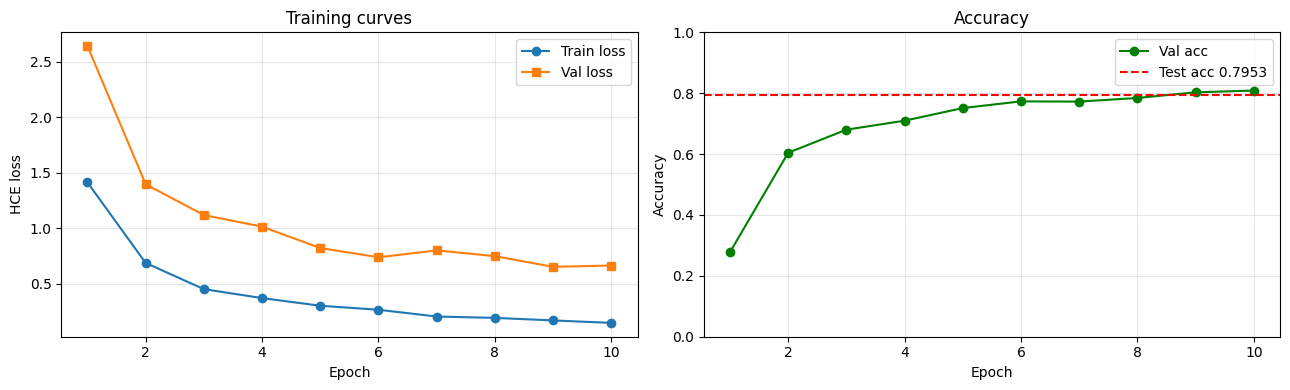

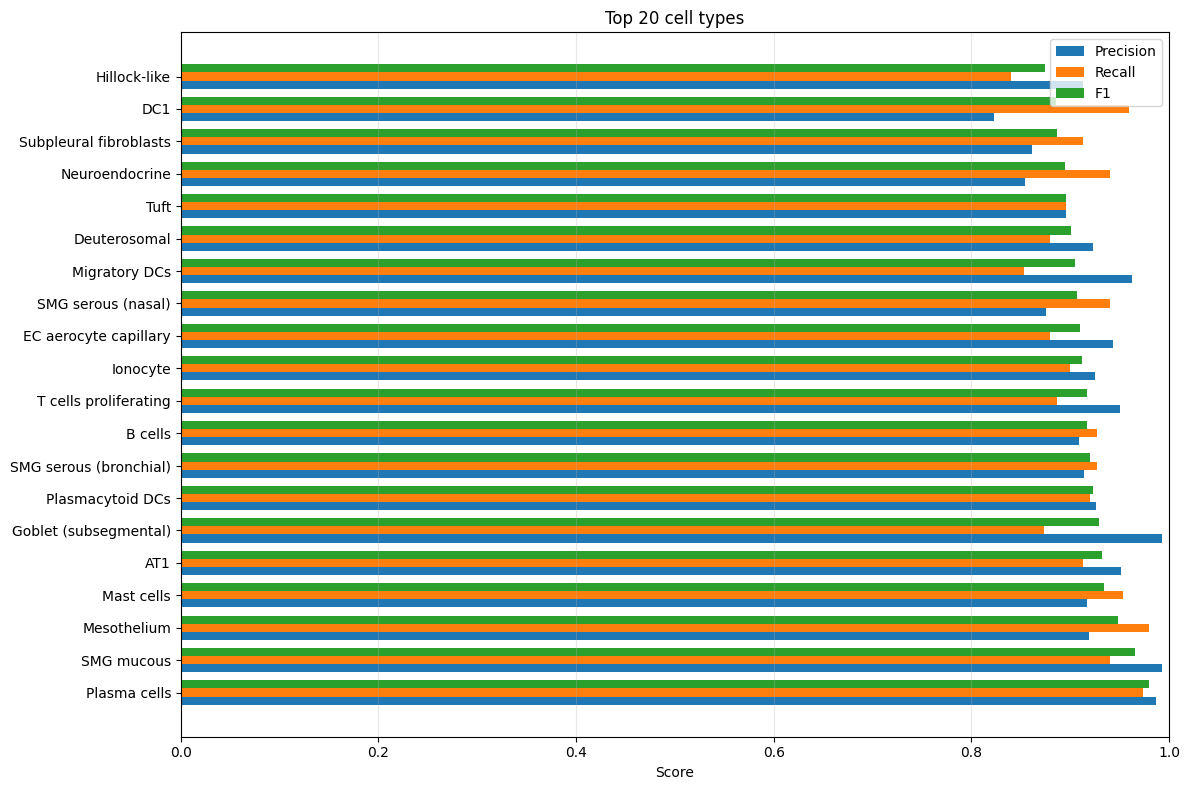

In [12]:
epochs = np.arange(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs, train_losses, "o-", label="Train loss")
axes[0].plot(epochs, val_losses,   "s-", label="Val loss")
axes[0].set(xlabel="Epoch", ylabel="HCE loss", title="Training curves"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(epochs, val_accs, "o-", color="green", label="Val acc")
axes[1].axhline(test_acc, ls="--", color="red", label=f"Test acc {test_acc:.4f}")
axes[1].set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy", ylim=[0,1]); axes[1].legend(); axes[1].grid(alpha=.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

# Per-class F1 bar chart (top 20)
top = per_class.head(20)
fig, ax = plt.subplots(figsize=(12, 8))
y = np.arange(len(top))
ax.barh(y - 0.25, top.precision, 0.25, label="Precision")
ax.barh(y,        top.recall,    0.25, label="Recall")
ax.barh(y + 0.25, top.f1,        0.25, label="F1")
ax.set(yticks=y, yticklabels=top.cell_type, xlabel="Score", title="Top 20 cell types")
ax.legend(); ax.grid(axis="x", alpha=.3); ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "per_class_f1.png"), dpi=150, bbox_inches="tight")
plt.show()


## 13. Confusion Matrix

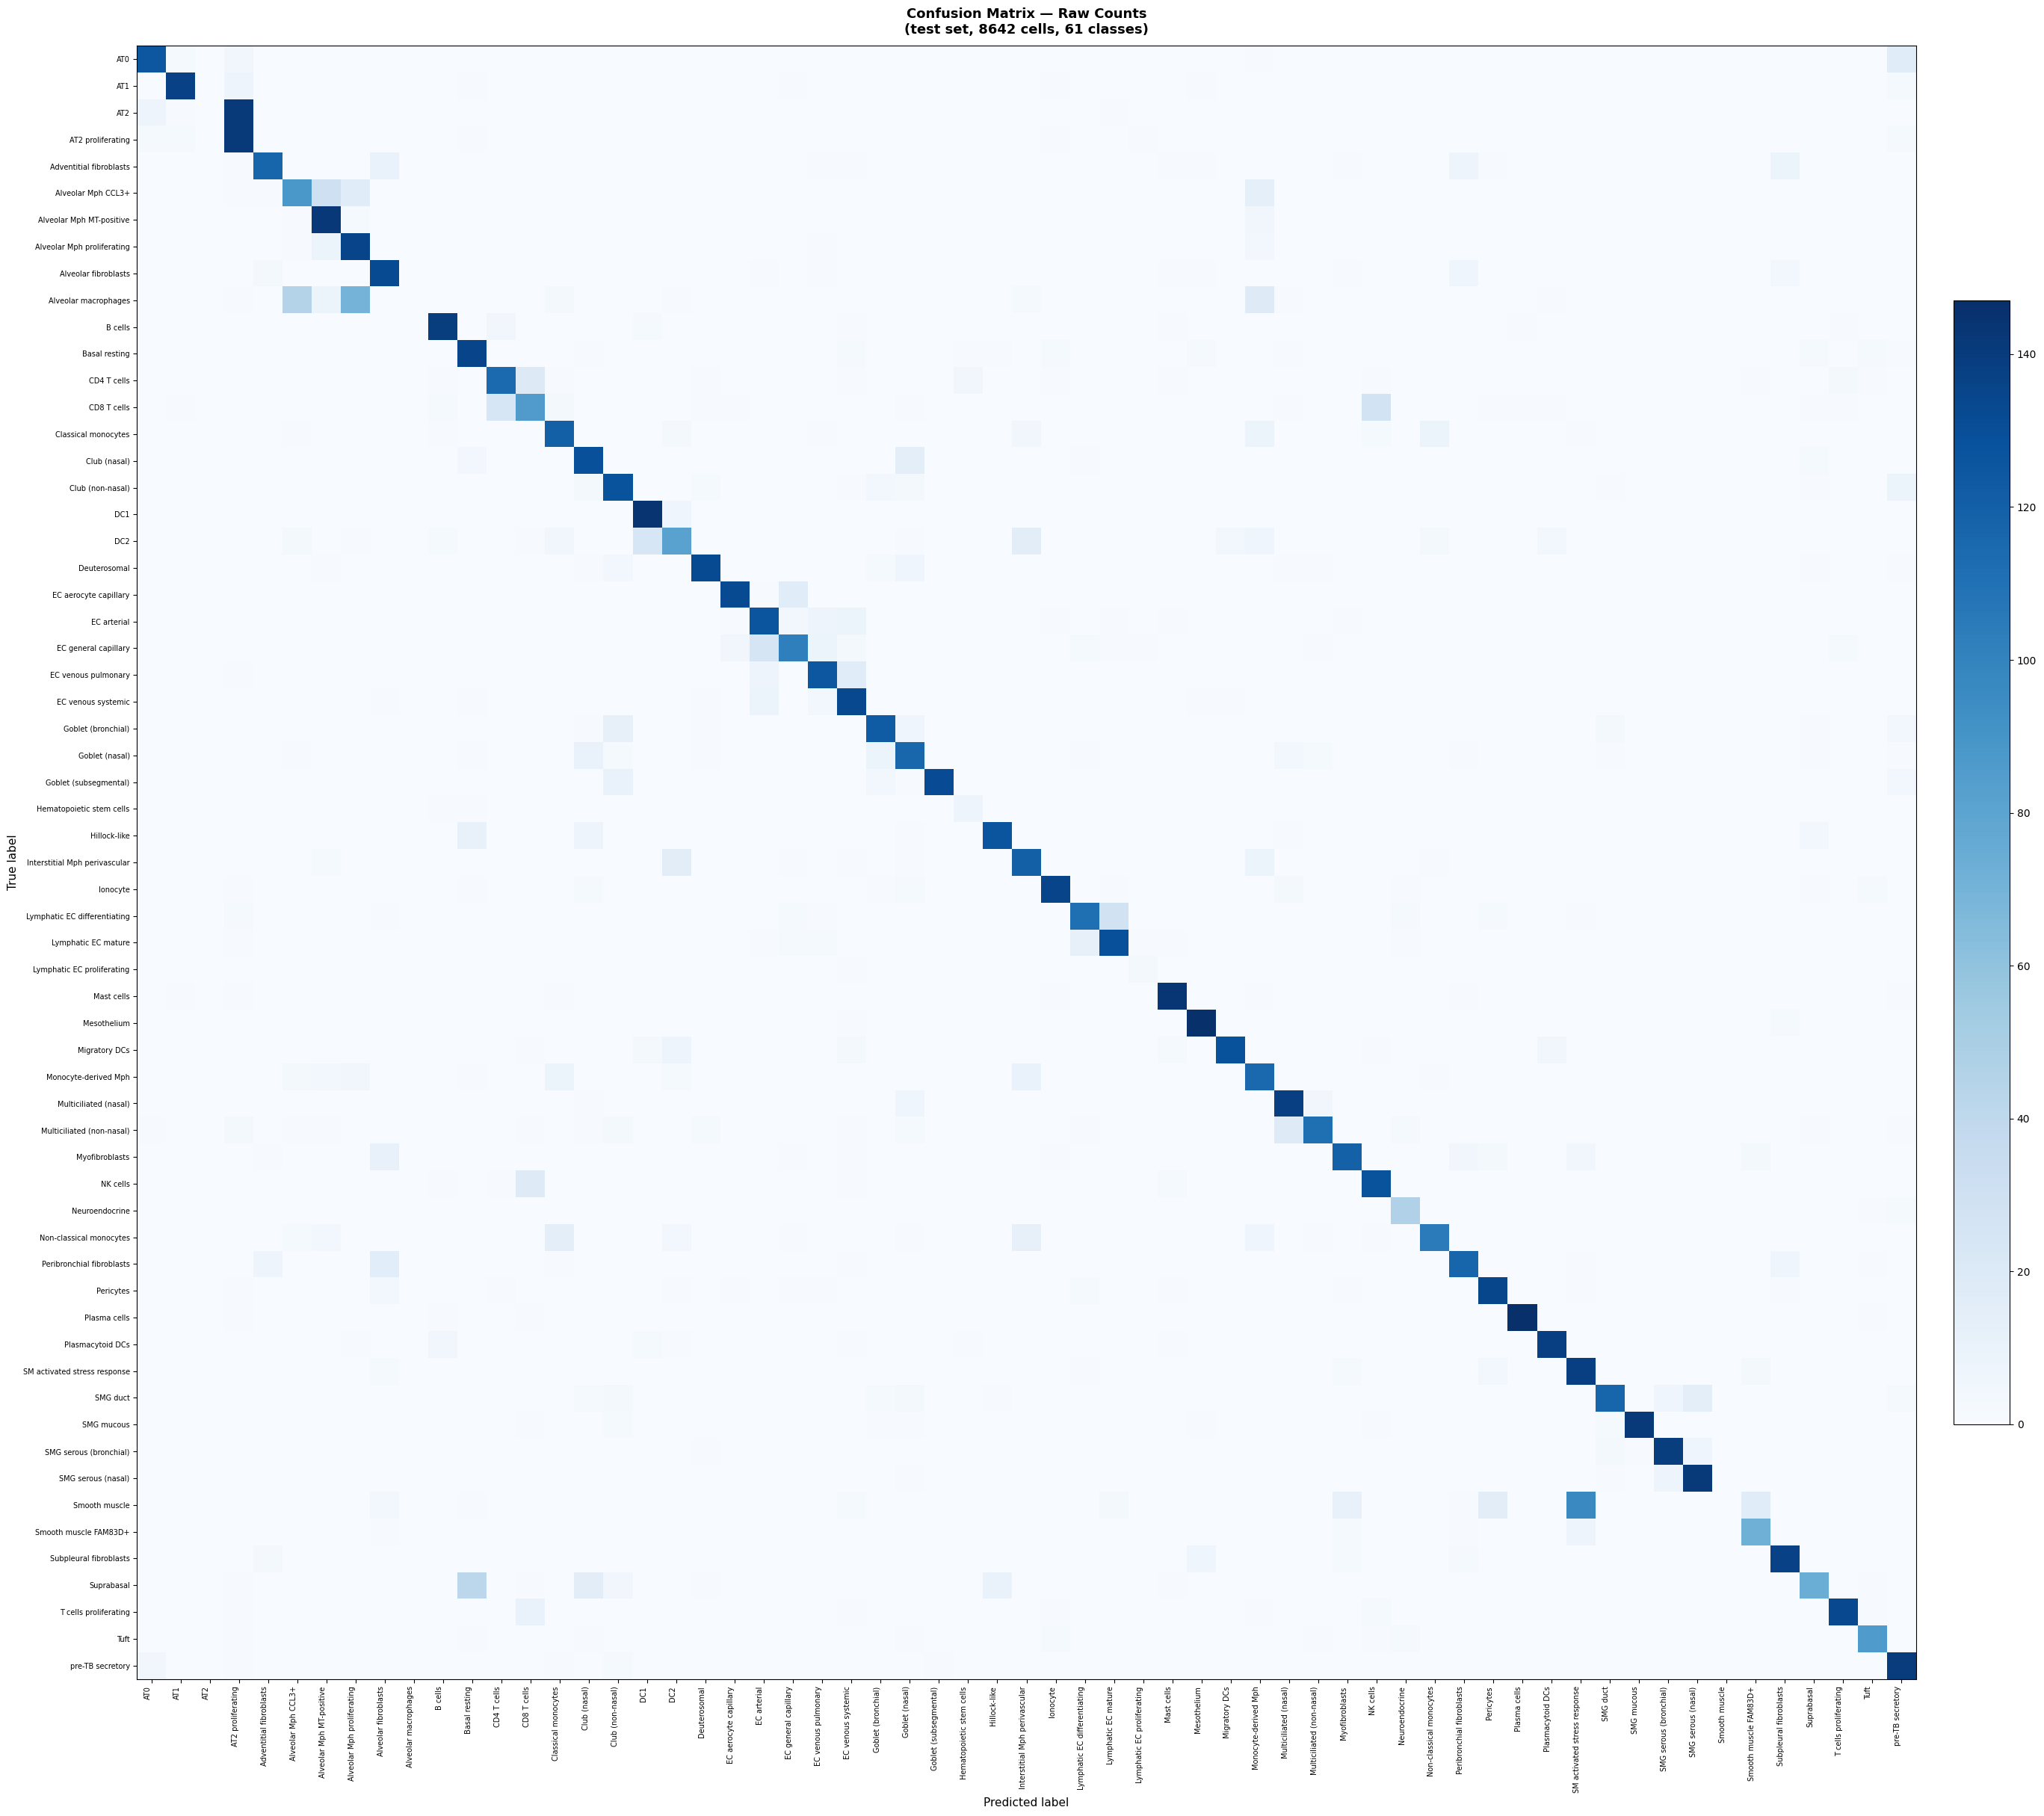

Saved → /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung_hce_option_a_results/confusion_matrix_raw.png


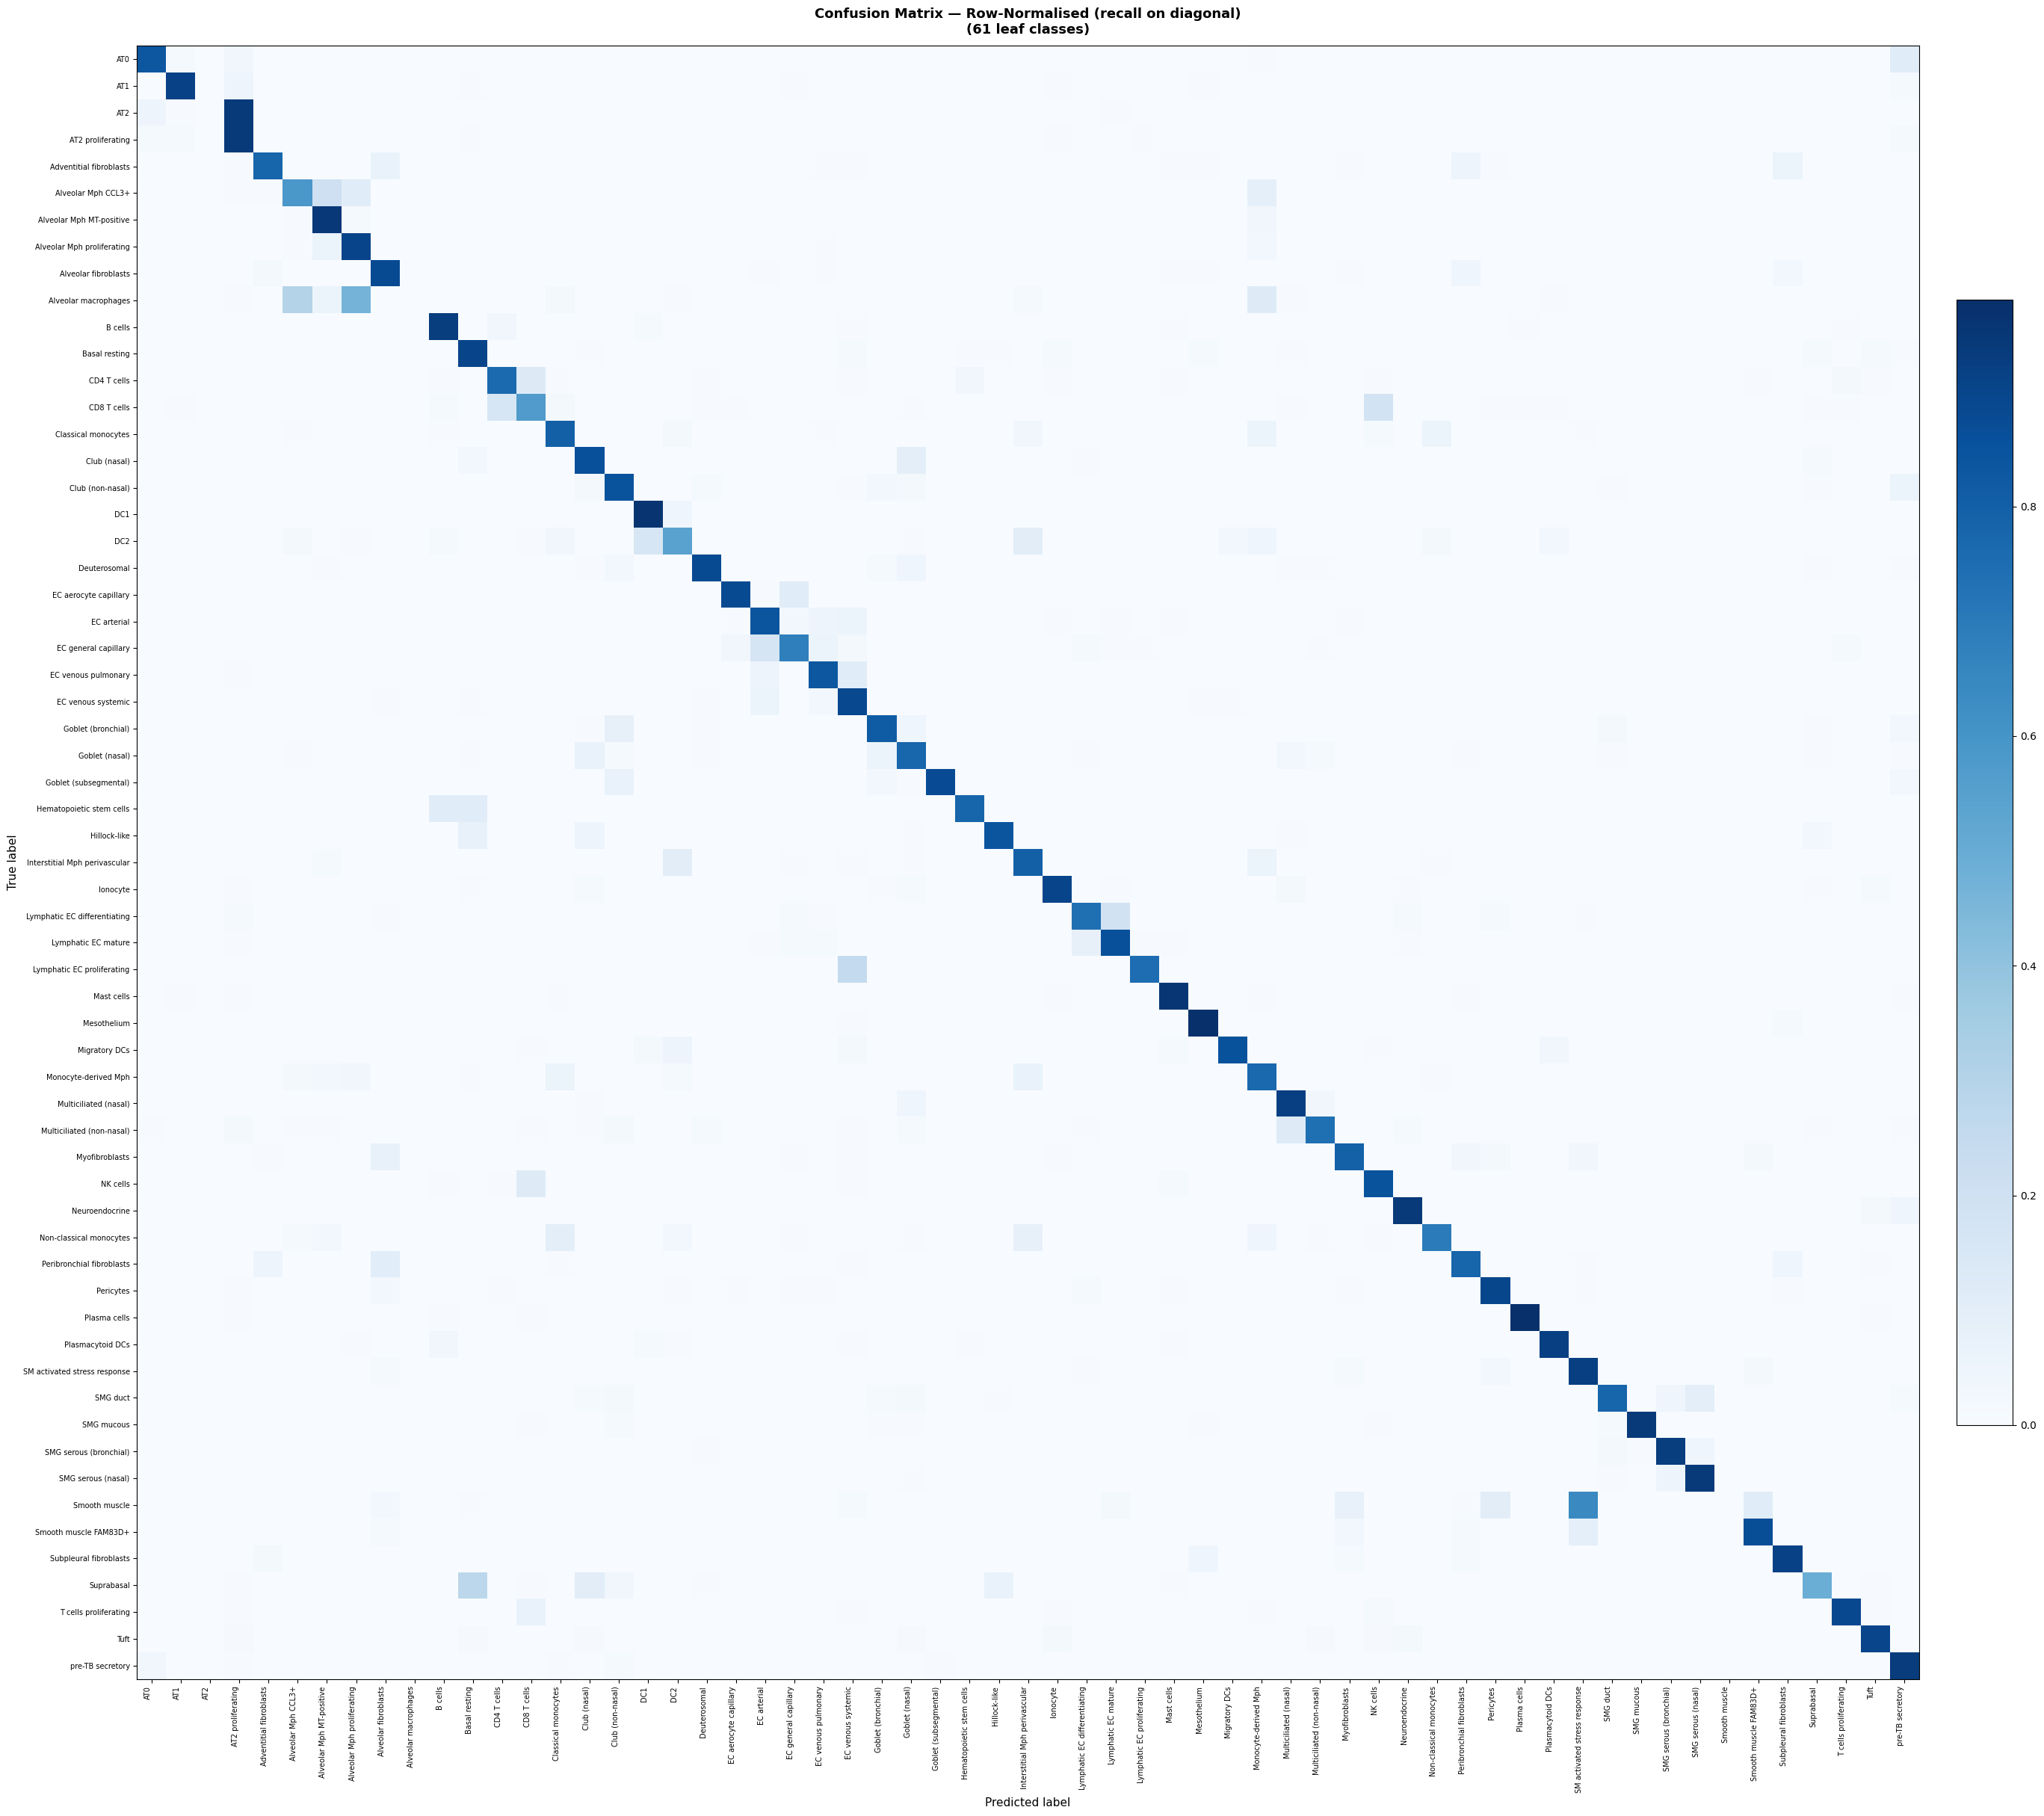

Saved → /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung_hce_option_a_results/confusion_matrix_norm.png

Top 20 misclassifications:
                  true_class                   pred_class  count  pct_of_true
                         AT2            AT2 proliferating    141     0.940000
               Smooth muscle SM activated stress response     96     0.640000
        Alveolar macrophages   Alveolar Mph proliferating     70     0.466667
        Alveolar macrophages           Alveolar Mph CCL3+     45     0.300000
                  Suprabasal                Basal resting     41     0.273333
          Alveolar Mph CCL3+     Alveolar Mph MT-positive     30     0.200000
Lymphatic EC differentiating          Lymphatic EC mature     28     0.186667
                 CD8 T cells                     NK cells     27     0.180000
        EC general capillary                  EC arterial     25     0.166667
                         DC2                          DC1     24

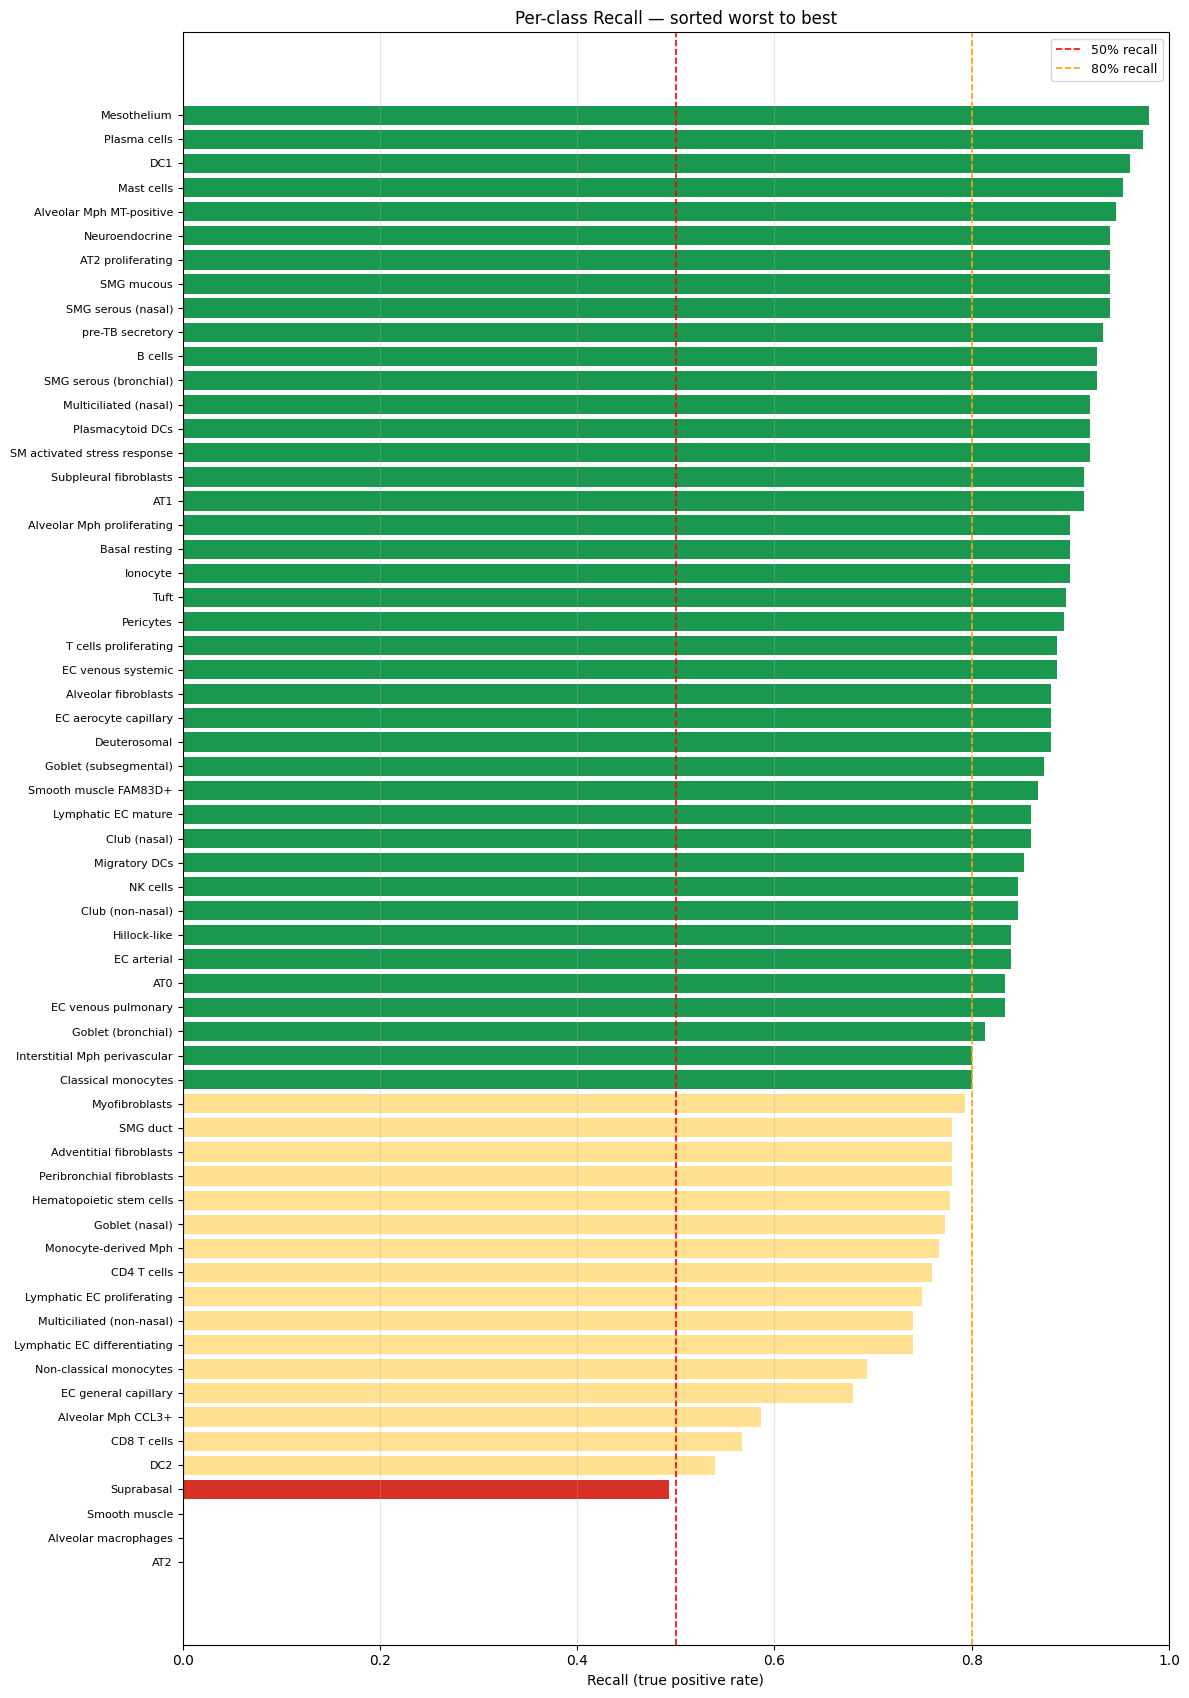

Saved → /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung_hce_option_a_results/per_class_recall.png

Recall summary across 61 leaf classes:
  Mean   : 0.7970
  Median : 0.8600
  Min    : 0.0000  (AT2)
  Max    : 0.9800  (Mesothelium)
  Classes with recall < 0.5 : 4
  Classes with recall >= 0.8: 41


In [13]:
# ── Full confusion matrix over all leaf (finest-level) classes ───────────────
# test_preds / test_trues are already projected to leaf indices (from cell 22).
# We build two views:
#   1. Raw counts       — shows absolute misclassification volume
#   2. Row-normalised   — shows per-class error rates (independent of class size)

cm_labels = leaf_indices          # ordered leaf class indices
cm_names  = [class_names[i] for i in cm_labels]   # human-readable names
n_classes = len(cm_labels)

cm_raw  = confusion_matrix(test_trues, test_preds, labels=cm_labels)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True).clip(min=1)

# ── helpers ──────────────────────────────────────────────────────────────────
def _plot_cm(mat, title, fmt, cmap, path, annot_thresh=0.0):
    """Plot a single confusion matrix and save to disk."""
    fig, ax = plt.subplots(figsize=(max(10, n_classes * 0.45),
                                    max(8,  n_classes * 0.40)))
    im = ax.imshow(mat, interpolation="nearest", cmap=cmap, aspect="auto",
                   vmin=0, vmax=mat.max())

    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label",      fontsize=11)

    ticks = np.arange(n_classes)
    ax.set_xticks(ticks); ax.set_xticklabels(cm_names, rotation=90,  ha="right", fontsize=7)
    ax.set_yticks(ticks); ax.set_yticklabels(cm_names, rotation=0,   fontsize=7)

    # Annotate cells above threshold (skip tiny values to avoid clutter)
    if n_classes <= 40:
        thresh = mat.max() * annot_thresh
        for i in range(n_classes):
            for j in range(n_classes):
                v = mat[i, j]
                if v > thresh:
                    color = "white" if v > mat.max() * 0.6 else "black"
                    ax.text(j, i, fmt.format(v), ha="center", va="center",
                            fontsize=6, color=color)

    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")

# ── 1. Raw count confusion matrix ────────────────────────────────────────────
_plot_cm(
    cm_raw,
    title=f"Confusion Matrix — Raw Counts\n(test set, {len(test_trues)} cells, {n_classes} classes)",
    fmt="{:.0f}",
    cmap="Blues",
    annot_thresh=0.05,
    path=os.path.join(OUT_DIR, "confusion_matrix_raw.png"),
)

# ── 2. Row-normalised confusion matrix (recall per class on diagonal) ─────────
_plot_cm(
    cm_norm,
    title=f"Confusion Matrix — Row-Normalised (recall on diagonal)\n({n_classes} leaf classes)",
    fmt="{:.2f}",
    cmap="Blues",
    annot_thresh=0.05,
    path=os.path.join(OUT_DIR, "confusion_matrix_norm.png"),
)

# ── 3. Top misclassifications table ──────────────────────────────────────────
rows = []
for i in range(n_classes):
    total_true = cm_raw[i].sum()
    if total_true == 0:
        continue
    for j in range(n_classes):
        if i != j and cm_raw[i, j] > 0:
            rows.append({
                "true_class":      cm_names[i],
                "pred_class":      cm_names[j],
                "count":           int(cm_raw[i, j]),
                "pct_of_true":     cm_raw[i, j] / total_true,
            })

misclass_df = (pd.DataFrame(rows)
               .sort_values("count", ascending=False)
               .reset_index(drop=True))

misclass_path = os.path.join(OUT_DIR, "top_misclassifications.csv")
misclass_df.to_csv(misclass_path, index=False)

print(f"\nTop 20 misclassifications:")
print(misclass_df.head(20).to_string(index=False))

# ── 4. Per-class recall bar chart (sorted worst → best) ──────────────────────
per_class_recall = pd.DataFrame({
    "cell_type": cm_names,
    "recall":    np.diag(cm_norm),
    "n_test":    cm_raw.sum(axis=1),
}).sort_values("recall")

fig, ax = plt.subplots(figsize=(12, max(6, n_classes * 0.28)))
colors = ["#d73027" if r < 0.5 else "#fee090" if r < 0.8 else "#1a9850"
          for r in per_class_recall.recall]
bars = ax.barh(per_class_recall.cell_type, per_class_recall.recall, color=colors)
ax.axvline(0.5, color="red",    ls="--", lw=1.2, label="50% recall")
ax.axvline(0.8, color="orange", ls="--", lw=1.2, label="80% recall")
ax.set(xlabel="Recall (true positive rate)", title="Per-class Recall — sorted worst to best",
       xlim=[0, 1])
ax.legend(fontsize=9)
ax.tick_params(axis="y", labelsize=8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
recall_path = os.path.join(OUT_DIR, "per_class_recall.png")
plt.savefig(recall_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {recall_path}")

# ── 5. Summary stats ──────────────────────────────────────────────────────────
diag_recall = np.diag(cm_norm)
print(f"\nRecall summary across {n_classes} leaf classes:")
print(f"  Mean   : {diag_recall.mean():.4f}")
print(f"  Median : {np.median(diag_recall):.4f}")
print(f"  Min    : {diag_recall.min():.4f}  ({cm_names[diag_recall.argmin()]})")
print(f"  Max    : {diag_recall.max():.4f}  ({cm_names[diag_recall.argmax()]})")
print(f"  Classes with recall < 0.5 : {(diag_recall < 0.5).sum()}")
print(f"  Classes with recall >= 0.8: {(diag_recall >= 0.8).sum()}")
